In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ei = pd.read_csv(r"C:\Users\musta\Downloads\economic_index.csv")

In [11]:
ei.head(5)

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [13]:
ei.drop(columns=['Unnamed: 0','year','month'], axis =1, inplace = True)

KeyError: "['Unnamed: 0', 'year', 'month'] not found in axis"

In [ ]:
ei.head()

In [16]:
ei.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

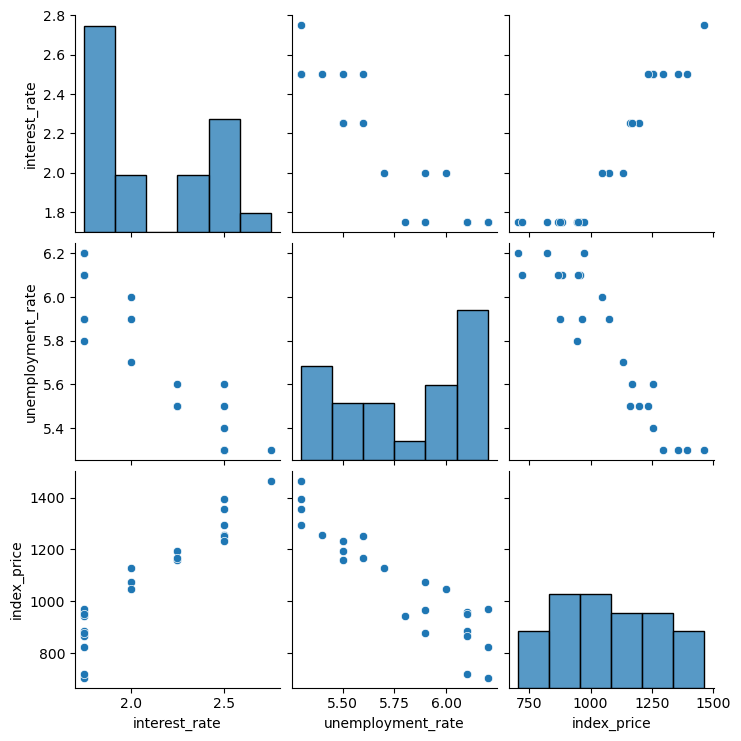

In [20]:
import seaborn as sns
sns.pairplot(ei)

sns.

In [22]:
ei.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


In [153]:
x = ei.iloc[:,:-1]
y = ei.iloc[:,-1]


In [155]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size = 0.25, random_state = 42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

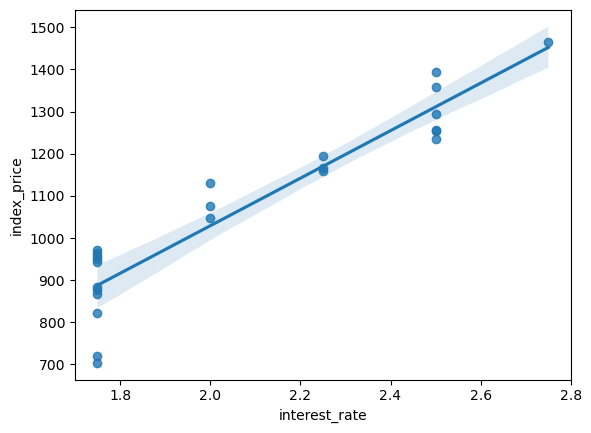

In [157]:
import seaborn as sns
sns.regplot(x='interest_rate', y='index_price', data=ei)


In [159]:
from sklearn.preprocessing import StandardScaler

In [161]:
scaler = StandardScaler()

In [163]:
scaler.fit_transform(X_train) 
scaler.fit_transform(X_test)

array([[ 0.36115756, -0.82078268],
       [-1.08347268,  1.33377186],
       [ 1.8057878 , -1.43636969],
       [-1.08347268,  1.02597835],
       [-0.36115756,  0.41039134],
       [ 0.36115756, -0.51298918]])

In [108]:
from sklearn.linear_model import LinearRegression

In [110]:
regression = LinearRegression()

In [112]:
regression.fit(X_train, y_train)

LinearRegression()

In [114]:
#Cross Validation
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regression, X_train, y_train, scoring = 'neg_mean_squared_error', cv =3 )

In [116]:
validation_score

array([-4921.61331265, -7686.87497294, -5135.9962549 ])

In [118]:
#Prediction

y_pred = regression.predict(X_test)
y_pred

array([1204.22770398,  821.65051903, 1406.51300368,  857.70889608,
        994.90992298, 1168.16932693])

In [120]:
# Performance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

In [122]:
print(mse)
print(mae)
print(rmse)

5793.762887712565
59.935781523235505
76.11677139574803


In [124]:
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)

print(score)

# adjusted R-Square
1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.8278978091457146


0.7131630152428577

# Assumptions

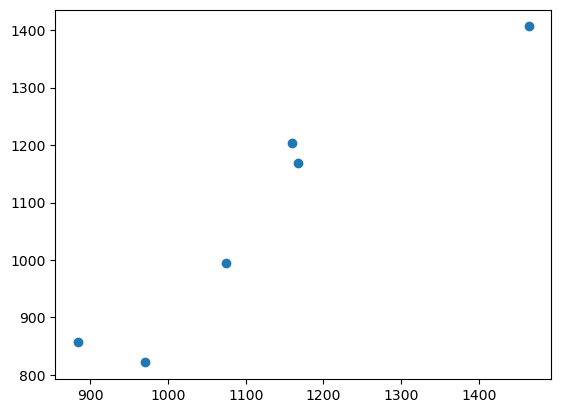

In [127]:
plt.scatter(y_test,y_pred)

In [145]:
residuals = y_test - y_pred
residuals

8     -45.227704
16    149.349481
0      57.486996
18     26.291104
11     80.090077
9      -1.169327
Name: index_price, dtype: float64

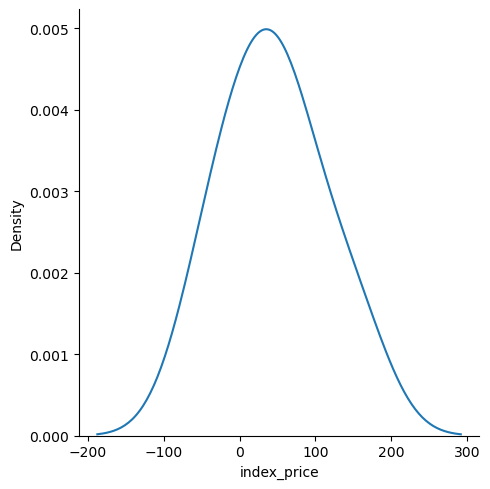

In [131]:
sns.displot(residuals, kind ='kde')

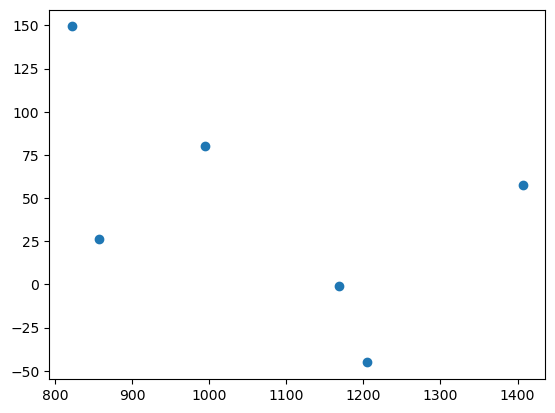

In [133]:
# Create scatter plot with residuals and prediction
plt.scatter(y_pred, residuals)

In [135]:
#OLS

import statsmodels.api as sm
model = sm.OLS(y_train, X_train).fit()

predicted_model = model.predict(X_test)

In [137]:
predicted_model

8     1169.232446
16     869.856341
0     1458.321844
18     871.913683
11    1018.515723
9     1167.175105
dtype: float64

In [139]:
model.summary()

C:\Users\musta\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=18
  res = hypotest_fun_out(*samples, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:            index_price   R-squared (uncentered):                   0.995
Model:                            OLS   Adj. R-squared (uncentered):              0.994
Method:                 Least Squares   F-statistic:                              1468.
Date:                Sun, 12 Jan 2025   Prob (F-statistic):                    7.46e-19
Time:                        12:28:22   Log-Likelihood:                         -104.21
No. Observations:                  18   AIC:                                      212.4
Df Residuals:                      16   BIC:                                      214.2
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
interest_rate       569.9494     44.349     12.851      0.000     475.933     663.965
unemployment_rate   -20.5734     15.966     -1.289      0.216     -54.421      13.274
==============================================================================
Omnibus:                        1.657   Durbin-Watson:                   1.707
Prob(Omnibus):                  0.437   Jarque-Bera (JB):                1.346
Skew:                          -0.611   Prob(JB):                        0.510
Kurtosis:                       2.451   Cond. No.                         14.6
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [147]:
regression.coef_

array([ 260.33709119, -360.58377051])